In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/AI/Datasets/Experience-Salary.csv")
df.rename(columns={'exp(in months)':'experience_months','salary(in thousands)':'salary_thousands'},inplace=True)


df

,experience_months,salary_thousands
0,18.290293,16.521825
1,17.023407,11.666234
2,26.343613,23.167255
3,19.105834,20.877145
4,27.742516,23.166236
...,...,...
995,22.161741,24.666502
996,32.266497,24.160270
997,17.039030,19.903797
998,25.222124,21.974413


In [ ]:
x=df[["experience_months"]]
y=df[["salary_thousands"]]


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
len(x_train), len(x_test), len(y_train), len(y_test)


(800, 200, 800, 200)

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [ ]:
#test the model
lr.predict(x_test)

In [ ]:
lr.score(x_test,y_test)

0.6398280670467469

In [ ]:
import numpy as np

# Reshape x_train and y_train for gradient descent if they are pandas DataFrames
x_train_gd = x_train.values.flatten()
y_train_gd = y_train.values.flatten()

# Initialize parameters
m = 0 # slope
b = 0 # intercept

# Hyperparameters
learning_rate = 0.001
iterations = 10000

n = len(x_train_gd) # Number of training examples

# Gradient Descent function
def gradient_descent(x, y, m, b, learning_rate, iterations):
    costs = []
    for i in range(iterations):
        # Calculate predictions
        y_pred = m * x + b

        # Calculate gradients
        dm = (-2/n) * np.sum(x * (y - y_pred))
        db = (-2/n) * np.sum(y - y_pred)

        # Update parameters
        m = m - learning_rate * dm
        b = b - learning_rate * db

        # Calculate and store cost (Mean Squared Error)
        cost = (1/n) * np.sum(np.square(y - y_pred))
        costs.append(cost)

        if i % 1000 == 0:
            print(f"Iteration {i}: Cost = {cost:.4f}, m = {m:.4f}, b = {b:.4f}")

    return m, b, costs

# Run Gradient Descent
m_gd, b_gd, costs = gradient_descent(x_train_gd, y_train_gd, m, b, learning_rate, iterations)

print(f"\nFinal parameters after Gradient Descent: m = {m_gd:.4f}, b = {b_gd:.4f}")

# Make predictions on test set using GD parameters
x_test_gd = x_test.values.flatten()
y_pred_gd = m_gd * x_test_gd + b_gd

# Evaluate the model (Mean Squared Error on test set)
mse_gd = np.mean(np.square(y_test.values.flatten() - y_pred_gd))
print(f"Mean Squared Error on Test Set (Gradient Descent): {mse_gd:.4f}")

# Compare with LinearRegression from sklearn if needed
print(f"\nLinearRegression (sklearn) coefficients: m = {lr.coef_[0][0]:.4f}, b = {lr.intercept_[0]:.4f}")

Iteration 0: Cost = 789.5151, m = 1.5152, b = 0.0533
Iteration 1000: Cost = 28.5971, m = 0.9686, b = 1.0027
Iteration 2000: Cost = 27.9732, m = 0.9414, b = 1.7906
Iteration 3000: Cost = 27.5591, m = 0.9193, b = 2.4325
Iteration 4000: Cost = 27.2841, m = 0.9012, b = 2.9556
Iteration 5000: Cost = 27.1016, m = 0.8866, b = 3.3817
Iteration 6000: Cost = 26.9804, m = 0.8746, b = 3.7290
Iteration 7000: Cost = 26.9000, m = 0.8648, b = 4.0119
Iteration 8000: Cost = 26.8466, m = 0.8569, b = 4.2424
Iteration 9000: Cost = 26.8112, m = 0.8504, b = 4.4302

Final parameters after Gradient Descent: m = 0.8451, b = 4.5830
Mean Squared Error on Test Set (Gradient Descent): 26.8110

LinearRegression (sklearn) coefficients: m = 0.8219, b = 5.2562


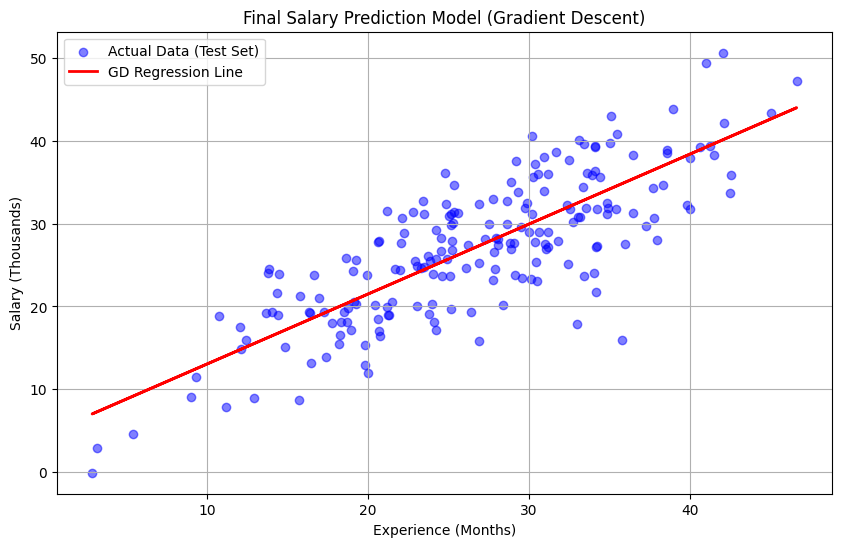

Final Model Equation: Salary = 0.8451 * Experience + 4.5830


In [ ]:
def final_predict(experience):
    """
    Predict salary based on experience (in months) using
    the parameters obtained from Gradient Descent.
    """
    return m_gd * experience + b_gd

# Visualize the final model
plt.figure(figsize=(10, 6))
plt.scatter(x_test_gd, y_test.values.flatten(), color='blue', alpha=0.5, label='Actual Data (Test Set)')
plt.plot(x_test_gd, y_pred_gd, color='red', linewidth=2, label='GD Regression Line')
plt.xlabel('Experience (Months)')
plt.ylabel('Salary (Thousands)')
plt.title('Final Salary Prediction Model (Gradient Descent)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Model Equation: Salary = {m_gd:.4f} * Experience + {b_gd:.4f}")

In [ ]:
import pickle

# Prepare the model data (coefficients)
model_data = {
    'slope': m_gd,
    'intercept': b_gd
}

# Save to a pickle file
model_filename = 'salary_model_gd.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(model_data, file)

print(f"Model saved successfully to {model_filename}")

# To save the sklearn version as well:
with open('salary_model_sklearn.pkl', 'wb') as f:
    pickle.dump(lr, f)
print("Sklearn model saved to salary_model_sklearn.pkl")

Model saved successfully to salary_model_gd.pkl
Sklearn model saved to salary_model_sklearn.pkl
